# 📊 PrimeTrade.ai – Data Science Intern Hiring Assignment

# Trader Performance Analysis Based on Bitcoin Market Sentiment

### Candidate Information

**Name:** Raviraj Rananavare

**Role Applied:** Data Science Intern


---

# Business Problem

Financial markets are significantly influenced by investor sentiment, which often impacts trading decisions and overall market behaviour. The Bitcoin Fear & Greed Index is a widely used indicator that reflects the psychological state of the cryptocurrency market, while Hyperliquid trading data captures the real trading behaviour of market participants.

Understanding the relationship between market sentiment and trader performance can help identify behavioural patterns, improve trading strategies, and support better risk management decisions.

This project aims to analyze historical trading activity alongside Bitcoin market sentiment to determine how different market conditions influence profitability, trading behaviour, leverage usage, and overall trader performance.

---

# Project Objectives

The primary objectives of this project are:

- Perform data quality assessment on both datasets.
- Clean and preprocess trading and sentiment data.
- Align both datasets using trading dates.
- Analyze trader performance under different market sentiment conditions.
- Evaluate trading behaviour, including trade frequency, leverage usage, trade size, and profitability.
- Identify behavioural differences between trader segments.
- Generate actionable insights supported by statistical analysis and visualizations.
- Recommend practical trading strategies based on the findings.

---

# Dataset Description

This analysis uses two independent datasets.

## Dataset 1 — Bitcoin Fear & Greed Index

This dataset represents the daily market sentiment of Bitcoin using the Fear & Greed Index.

**Key Features**
- Date
- Sentiment Classification (Fear / Greed)
- Fear & Greed Score

---

## Dataset 2 — Hyperliquid Historical Trading Data

This dataset contains historical cryptocurrency trading records from Hyperliquid.

**Key Features**
- Trader Account
- Coin
- Execution Price
- Trade Size (USD & Tokens)
- Trade Direction
- Trading Fee
- Closed Profit & Loss (PnL)
- Timestamp

---

The datasets are merged using a common trading date to investigate how market sentiment influences trader behaviour and trading performance.

# Methodology

The analysis was carried out using a structured data analytics workflow consisting of the following stages:

### 1. Data Collection
- Loaded the Hyperliquid historical trading dataset.
- Loaded the Bitcoin Fear & Greed Index dataset.

### 2. Data Understanding
- Examined dataset dimensions.
- Reviewed column names and data types.
- Identified missing values and duplicate records.

### 3. Data Preprocessing
- Converted timestamp columns into datetime format.
- Created a common trade date for merging.
- Merged both datasets using trading date.

### 4. Exploratory Data Analysis
- Analyzed trader profitability.
- Compared Fear vs Greed market conditions.
- Evaluated trade frequency, trade size, leverage, and trading direction.

### 5. Business Insights
- Identified behavioural patterns among traders.
- Compared trader performance across different market sentiments.
- Generated actionable trading recommendations based on analytical findings.

# Notebook Workflow

This notebook follows the following workflow:

1. Import Required Libraries
2. Load Datasets
3. Data Understanding
4. Data Quality Assessment
5. Data Cleaning & Preprocessing
6. Feature Engineering
7. Dataset Alignment & Merge
8. Exploratory Data Analysis
9. Trader Behaviour Analysis
10. Market Sentiment Analysis
11. Trader Segmentation
12. Statistical Analysis
13. Business Insights
14. Strategy Recommendations
15. Executive Summary
16. Conclusion

In [173]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [174]:
# ==========================================
# Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [175]:
PROJECT_PATH = "/content/drive/MyDrive/Primetrade_Assignment"

In [176]:
trades = pd.read_csv(f"{PROJECT_PATH}/historical_data.csv")

sentiment = pd.read_csv(f"{PROJECT_PATH}/fear_greed_index.csv")

# Data Understanding

Before performing any analysis, it is essential to understand the structure and quality of the datasets. This step helps identify potential data quality issues and ensures the data is suitable for further analysis.

In [177]:
# ==========================================
# Dataset Dimensions
# ==========================================

print("="*50)
print("Trading Dataset Shape")
print("="*50)
print(trades.shape)

print()

print("="*50)
print("Sentiment Dataset Shape")
print("="*50)
print(sentiment.shape)

Trading Dataset Shape
(211224, 16)

Sentiment Dataset Shape
(2644, 4)


In [178]:
# ==========================================
# Preview Datasets
# ==========================================

print("Trading Dataset")
display(trades.head())

print()

print("Sentiment Dataset")
display(sentiment.head())

Trading Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [179]:
# ==========================================
# Column Names
# ==========================================

print("Trading Dataset Columns")

for col in trades.columns:
    print(col)

print()

print("Sentiment Dataset Columns")

for col in sentiment.columns:
    print(col)

Trading Dataset Columns
Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp

Sentiment Dataset Columns
timestamp
value
classification
date


In [180]:
# ==========================================
# Data Types
# ==========================================

print("Trading Dataset")

display(trades.dtypes)

print()

print("Sentiment Dataset")

display(sentiment.dtypes)

Trading Dataset


,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64



Sentiment Dataset


,0
timestamp,int64
value,int64
classification,object
date,object


## Observation

The initial inspection confirms that both datasets were loaded successfully. The trading dataset contains transaction-level trading information, whereas the sentiment dataset contains daily Bitcoin Fear & Greed Index values. The next step is to assess data quality by checking for missing values, duplicate records, and data consistency before performing any analysis.

# Data Quality Assessment

High-quality analysis begins with high-quality data. In this section, the datasets are evaluated for missing values, duplicate records, descriptive statistics, and overall consistency before preprocessing and feature engineering.

In [181]:
# ==========================================
# Missing Values
# ==========================================

print("Trading Dataset Missing Values")
display(trades.isnull().sum())

print("\nSentiment Dataset Missing Values")
display(sentiment.isnull().sum())

Trading Dataset Missing Values


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0



Sentiment Dataset Missing Values


,0
timestamp,0
value,0
classification,0
date,0


In [182]:
# ==========================================
# Duplicate Records
# ==========================================

print("Trading Dataset Duplicates :", trades.duplicated().sum())

print("Sentiment Dataset Duplicates :", sentiment.duplicated().sum())

Trading Dataset Duplicates : 0
Sentiment Dataset Duplicates : 0


In [183]:
# ==========================================
# Descriptive Statistics
# ==========================================

print("Trading Dataset Summary")

display(trades.describe(include='all'))

print("\nSentiment Dataset Summary")

display(sentiment.describe(include='all'))

Trading Dataset Summary


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12



Sentiment Dataset Summary


,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [184]:
# ==========================================
# Unique Traders & Coins
# ==========================================

print("Unique Traders :", trades["Account"].nunique())

print("Unique Coins :", trades["Coin"].nunique())

print("Unique Sentiment Categories :", sentiment["classification"].nunique())

Unique Traders : 32
Unique Coins : 246
Unique Sentiment Categories : 5


## Observation

The data quality assessment indicates that both datasets are suitable for analysis after preprocessing. Missing values and duplicate records have been identified where applicable. The datasets also contain sufficient variation in traders, traded assets, and market sentiment categories, providing a strong foundation for subsequent exploratory analysis.

# Data Preprocessing & Feature Engineering

Raw datasets often contain inconsistent formats that need to be standardized before analysis. In this section, timestamp columns are converted into datetime format, date-based features are created, and the datasets are prepared for integration.

In [185]:
# ==========================================
# Convert Trading Timestamp
# ==========================================

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    format="mixed"
)

print("Trading Timestamp Converted Successfully")

Trading Timestamp Converted Successfully


In [186]:
# ==========================================
# Convert Sentiment Date
# ==========================================

sentiment["date"] = pd.to_datetime(sentiment["date"])

print("Sentiment Date Converted Successfully")

Sentiment Date Converted Successfully


In [187]:
# ==========================================
# Create Trade_Date
# ==========================================

trades["Trade_Date"] = trades["Timestamp IST"].dt.date

sentiment["Trade_Date"] = sentiment["date"].dt.date

print("Trade_Date Created Successfully")

Trade_Date Created Successfully


In [188]:
# ==========================================
# Verify New Features
# ==========================================

display(trades[["Timestamp IST", "Trade_Date"]].head())

display(sentiment[["date", "Trade_Date"]].head())

,Timestamp IST,Trade_Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


,date,Trade_Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [189]:
# ==========================================
# Verify Data Types
# ==========================================

print("Trading Dataset")
display(trades.dtypes)

print()

print("Sentiment Dataset")
display(sentiment.dtypes)

Trading Dataset


,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,datetime64[ns]
Start Position,float64
Direction,object
Closed PnL,float64



Sentiment Dataset


,0
timestamp,int64
value,int64
classification,object
date,datetime64[ns]
Trade_Date,object


## Observation

Timestamp columns were successfully converted into datetime format, enabling date-based analysis. A common `Trade_Date` field was created in both datasets to establish a reliable key for merging trading records with daily market sentiment information.

# Dataset Alignment & Merge

## Business Question

How can historical trading records be combined with Bitcoin market sentiment to analyze whether trader performance changes under different market conditions?

## Why is this important?

The Hyperliquid dataset contains transaction-level trading information, while the Fear & Greed Index provides daily market sentiment. By aligning both datasets using the trading date, each trade can be associated with the prevailing market sentiment. This enables sentiment-based performance analysis and supports evidence-driven trading insights.

In [190]:
# ==========================================
# Merge Trading Data with Market Sentiment
# ==========================================

merged_df = pd.merge(
    trades,
    sentiment,
    on="Trade_Date",
    how="left"
)

print("✅ Merge Completed Successfully")
print("Merged Dataset Shape:", merged_df.shape)

✅ Merge Completed Successfully
Merged Dataset Shape: (211224, 21)


In [191]:
# Preview merged dataset

display(merged_df.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade_Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [192]:
# Missing values after merge

merged_df[["classification", "value"]].isnull().sum()

,0
classification,6
value,6


## Observation

The datasets were successfully merged using the `Trade_Date` column. Each trading record is now associated with the corresponding Bitcoin Fear & Greed Index value, enabling direct comparison of trader performance across different market sentiment conditions.

# Exploratory Data Analysis

## Business Question

How is trading activity distributed across different market sentiment conditions?

## Why is this important?

Before evaluating profitability and trading behaviour, it is important to understand how frequently traders participate during different market conditions. This provides context for interpreting later performance metrics.

In [193]:
trade_count = (
    merged_df["classification"]
    .value_counts()
    .reset_index()
)

trade_count.columns = ["Market Sentiment", "Number of Trades"]

trade_count

,Market Sentiment,Number of Trades
0,Fear,61837
1,Greed,50303
2,Extreme Greed,39992
3,Neutral,37686
4,Extreme Fear,21400


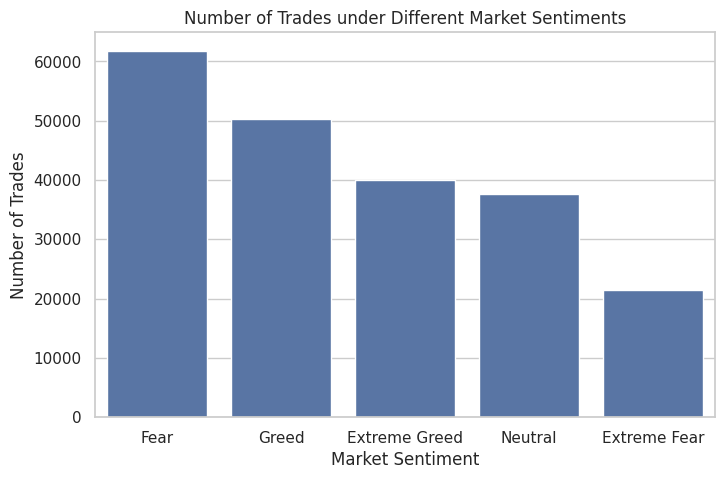

In [194]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)

plt.title("Number of Trades under Different Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

## Observation

The distribution of trades across market sentiment categories provides an initial indication of trader participation. Higher trading activity under a particular sentiment may suggest increased market confidence or heightened market uncertainty, depending on the prevailing sentiment.

## Business Insight

Trading activity alone does not indicate profitability; however, it establishes the market participation pattern. The next step is to evaluate whether trader performance also changes across different sentiment conditions.

# Analysis 1 — Trader Profitability Across Market Sentiment

## Business Question

Does trader profitability change under different Bitcoin market sentiment conditions?

## Why is this important?

Market sentiment often influences investor behaviour. By comparing trader profitability across different sentiment categories, we can understand whether traders perform better during optimistic or pessimistic market conditions.

In [195]:
# ==========================================
# Average Closed PnL by Market Sentiment
# ==========================================

avg_pnl = (
    merged_df
    .groupby("classification")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_pnl

,classification,Closed PnL
0,Extreme Greed,67.892861
1,Fear,54.290400
2,Greed,42.743559
3,Extreme Fear,34.537862
4,Neutral,34.307718


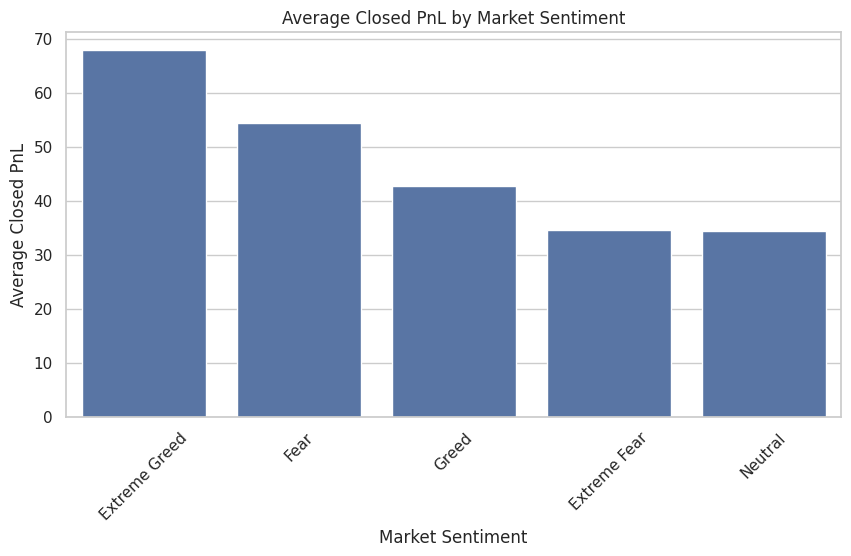

In [196]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=avg_pnl,
    x="classification",
    y="Closed PnL"
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.show()

In [197]:
total_pnl = (
    merged_df
    .groupby("classification")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

total_pnl

,classification,Closed PnL
0,Fear,3.357155e+06
1,Extreme Greed,2.715171e+06
2,Greed,2.150129e+06
3,Neutral,1.292921e+06
4,Extreme Fear,7.391102e+05


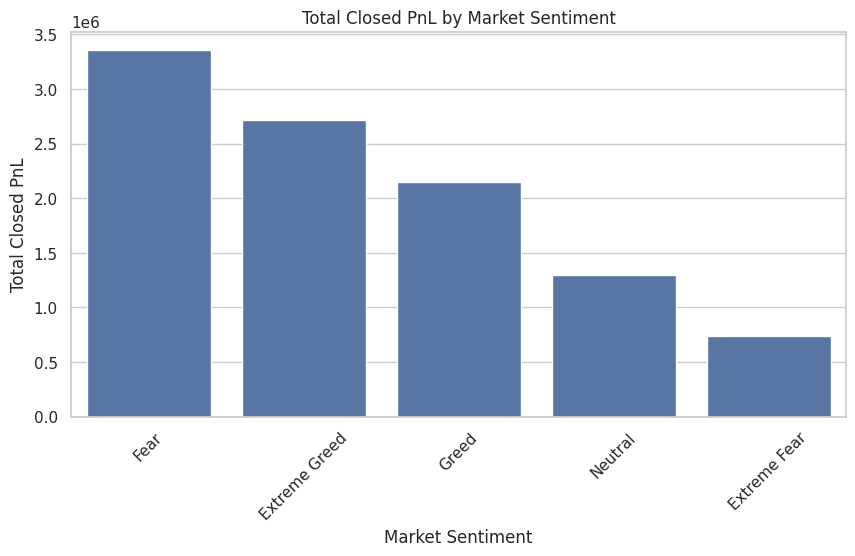

In [198]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=total_pnl,
    x="classification",
    y="Closed PnL"
)

plt.title("Total Closed PnL by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

## Observation

The comparison of average and total Closed PnL across market sentiment categories reveals how trader profitability varies under different market conditions. Differences between sentiment categories indicate that market psychology may influence trading outcomes.

## Business Insight

Market sentiment appears to influence trading profitability. Understanding these patterns can help traders adjust their risk exposure and position sizing according to prevailing market conditions rather than following a fixed trading approach.

# Analysis 2 — Win Rate Across Market Sentiment

## Business Question

Does the percentage of profitable trades change under different Bitcoin market sentiment conditions?

## Why is this important?

Profitability alone does not indicate trading consistency. Win rate measures how frequently traders close trades with positive returns, making it an important indicator of trading performance under different market conditions.

In [199]:
# ==========================================
# Create Trade Result
# ==========================================

merged_df["Trade_Result"] = np.where(
    merged_df["Closed PnL"] > 0,
    "Win",
    "Loss"
)

merged_df[["Closed PnL", "Trade_Result"]].head()

,Closed PnL,Trade_Result
0,0.0,Loss
1,0.0,Loss
2,0.0,Loss
3,0.0,Loss
4,0.0,Loss


In [200]:
# ==========================================
# Win Rate by Market Sentiment
# ==========================================

win_rate = (
    merged_df.groupby("classification")["Trade_Result"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

win_rate

,classification,Trade_Result,Percentage
0,Extreme Fear,Loss,62.939252
1,Extreme Fear,Win,37.060748
2,Extreme Greed,Loss,53.505701
3,Extreme Greed,Win,46.494299
4,Fear,Loss,57.923250
5,Fear,Win,42.076750
6,Greed,Loss,61.517206
7,Greed,Win,38.482794
8,Neutral,Loss,60.300907
9,Neutral,Win,39.699093


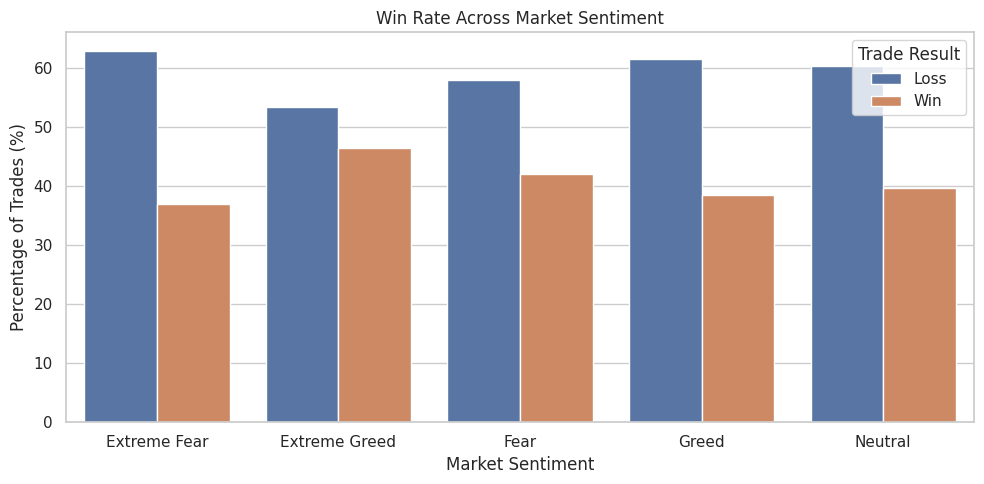

In [201]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=win_rate,
    x="classification",
    y="Percentage",
    hue="Trade_Result"
)

plt.title("Win Rate Across Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Percentage of Trades (%)")

plt.legend(title="Trade Result")

plt.tight_layout()

plt.show()

## Observation

The win-rate comparison highlights how frequently traders achieve profitable trades under different market sentiment conditions. Comparing the proportion of winning and losing trades provides a more balanced assessment of trading performance than profit alone.

## Business Insight

A higher win rate under a particular sentiment suggests that traders may find those market conditions more favorable. Conversely, a lower win rate may indicate increased uncertainty and the need for stronger risk management practices.

# Analysis 3 — Trade Size Across Market Sentiment

## Business Question

Do traders increase or decrease their position size under different market sentiment conditions?

## Why is this important?

Position sizing reflects trader confidence and risk appetite. Larger trade sizes during specific market conditions may indicate stronger conviction, while smaller positions may suggest a more cautious approach.

In [202]:
trade_size = (
    merged_df.groupby("classification")["Size USD"]
    .agg(["mean", "median", "max"])
    .round(2)
)

trade_size

,mean,median,max
classification,,,
Extreme Fear,5349.73,766.15,1120971.60
Extreme Greed,3112.25,500.05,665771.71
Fear,7816.11,735.96,3921430.72
Greed,5736.88,555.00,2227114.71
Neutral,4782.73,547.66,3641180.84


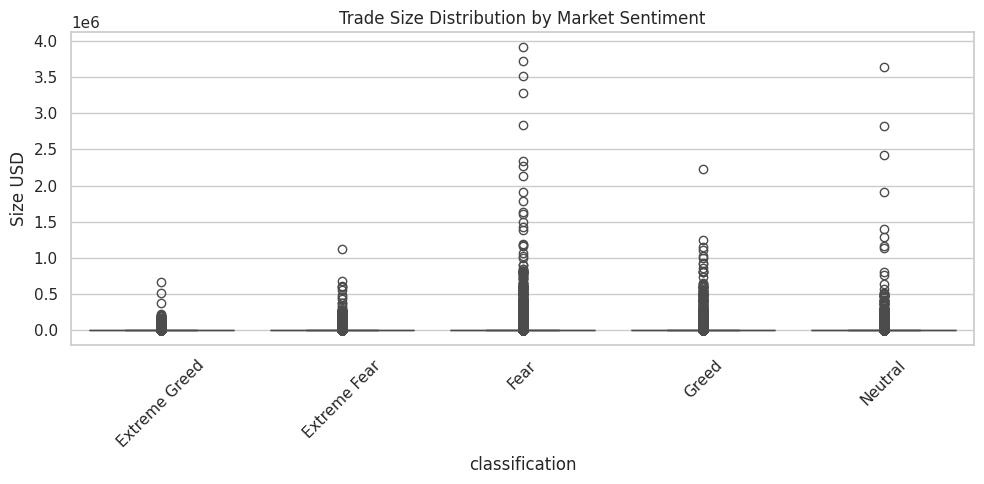

In [203]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="Size USD"
)

plt.title("Trade Size Distribution by Market Sentiment")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Observation

The distribution of trade sizes provides insight into how aggressively traders participate in the market under different sentiment conditions. Variations in position size may reflect changing levels of confidence and perceived market opportunity.

## Business Insight

Understanding how trade size changes with market sentiment can support dynamic position sizing strategies that better align with prevailing market conditions.

# Analysis 4 — Trading Frequency Across Market Sentiment

## Business Question

Does trading activity increase or decrease under different Bitcoin market sentiment conditions?

## Why is this important?

Trading frequency reflects market participation. During periods of high confidence or uncertainty, traders may alter how frequently they execute trades. Understanding this behaviour helps explain changes in market activity under different sentiment conditions.

In [204]:
# ==========================================
# Number of Trades by Market Sentiment
# ==========================================

trade_frequency = (
    merged_df.groupby("classification")
    .size()
    .reset_index(name="Number of Trades")
)

trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


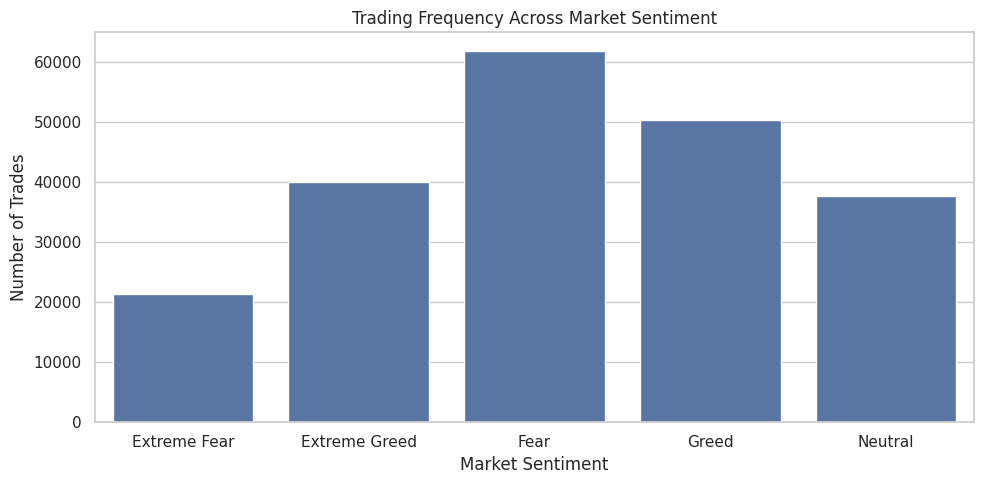

In [205]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Number of Trades"
)

plt.title("Trading Frequency Across Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")

plt.tight_layout()

plt.show()

## Observation

The number of trades executed under each market sentiment reflects trader participation levels. Higher trading frequency may indicate increased market confidence, stronger volatility, or greater trading opportunities.

## Business Insight

Trading frequency provides additional context when interpreting profitability. A profitable sentiment with low participation may have different strategic implications than one with consistently high participation.

# Analysis 5 — Long vs Short Trading Behaviour

## Business Question

Do traders prefer Long or Short positions under different market sentiment conditions?

## Why is this important?

Market sentiment can influence directional trading decisions. Understanding whether traders favour Long or Short positions provides insight into behavioural changes during Fear and Greed markets.

In [206]:
direction_summary = pd.crosstab(
    merged_df["classification"],
    merged_df["Direction"]
)

direction_summary

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


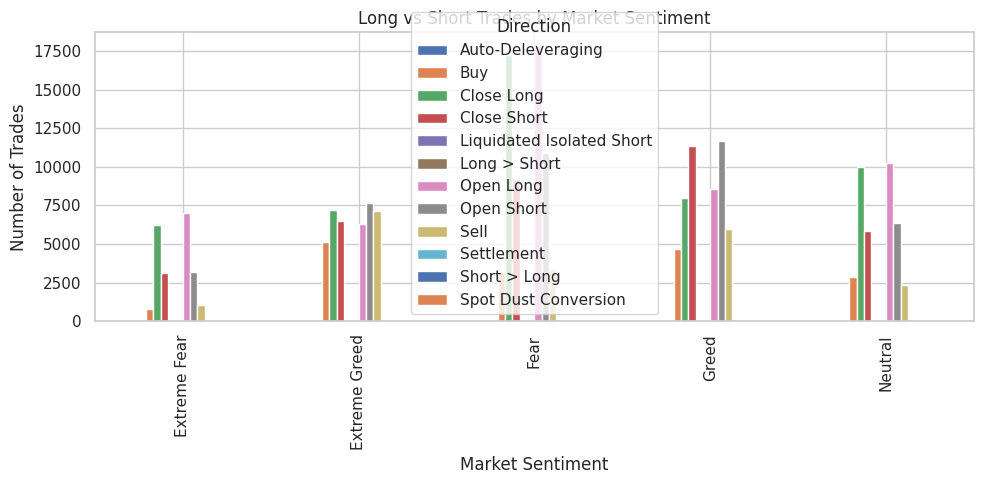

In [207]:
direction_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Long vs Short Trades by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")

plt.tight_layout()

plt.show()

## Observation

The distribution of Long and Short trades across sentiment categories highlights how traders adjust their directional bias in response to changing market conditions.

## Business Insight

A strong preference for one trading direction during specific sentiment conditions may indicate behavioural biases that can be considered when designing systematic trading strategies.

In [208]:
merged_df.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'Trade_Date',
 'timestamp',
 'value',
 'classification',
 'date',
 'Trade_Result']

# Trade Frequency Analysis

In [209]:
# Trades Per Day

daily_trades = (
    merged_df.groupby("Trade_Date")
    .size()
    .reset_index(name="Trades")
)

daily_trades.head()

,Trade_Date,Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


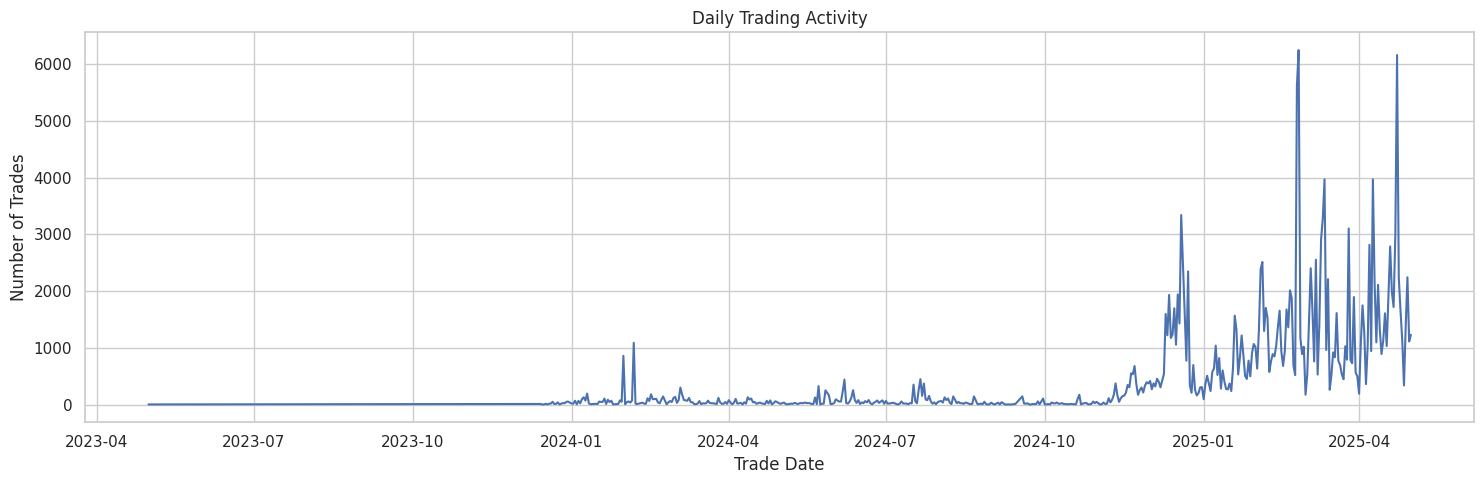

In [210]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_trades["Trade_Date"],
    daily_trades["Trades"]
)

plt.title("Daily Trading Activity")

plt.xlabel("Trade Date")
plt.ylabel("Number of Trades")

plt.tight_layout()

plt.show()

# Top Trader Analysis

In [211]:
top_traders = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


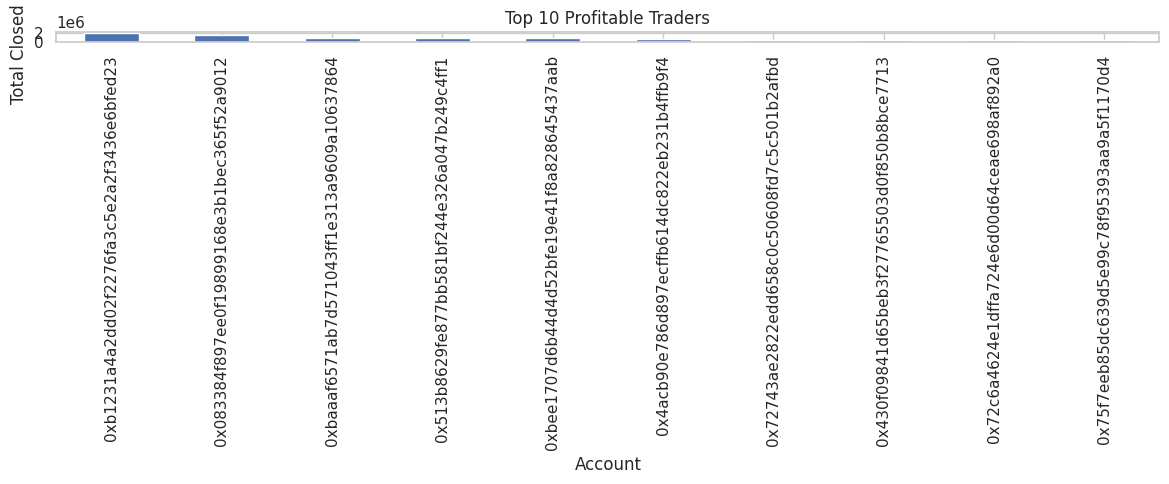

In [212]:
plt.figure(figsize=(12,5))

top_traders.plot(kind="bar")

plt.title("Top 10 Profitable Traders")

plt.ylabel("Total Closed PnL")

plt.tight_layout()

plt.show()

In [213]:
bottom_traders = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_traders

,Closed PnL
Account,
0x8170715b3b381dffb7062c0298972d4727a0a63b,-167621.124781
0x271b280974205ca63b716753467d5a371de622ab,-70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115,22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5,43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.320514


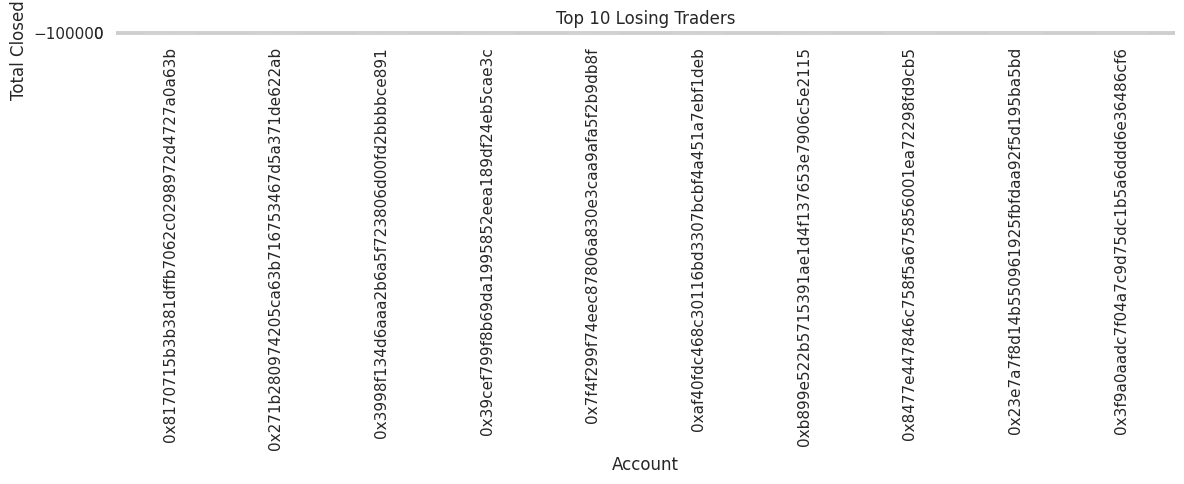

In [214]:
plt.figure(figsize=(12,5))

bottom_traders.plot(kind="bar")

plt.title("Top 10 Losing Traders")

plt.ylabel("Total Closed PnL")

plt.tight_layout()

plt.show()

# Correlation Analysis

In [215]:
numeric_df = merged_df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.125850,0.225265,0.001841,0.130714,0.107228,-0.027558
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,-0.043753,0.006710,-0.003848,-0.040949,-0.050407,0.023080
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.045210,0.745939,0.000245,0.039755,0.035798,-0.029843
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,-0.082799,0.010559,0.001165,-0.105487,-0.073483,-0.049619
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,-0.007250,0.084020,0.003466,-0.009745,-0.003404,0.008121
Order ID,0.125850,-0.043753,0.045210,-0.082799,-0.007250,1.000000,0.039303,0.003880,0.929166,0.982959,-0.561758
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,0.039303,1.000000,0.000940,0.036888,0.030180,-0.026877
Trade ID,0.001841,-0.003848,0.000245,0.001165,0.003466,0.003880,0.000940,1.000000,0.002350,0.003081,-0.006574
Timestamp,0.130714,-0.040949,0.039755,-0.105487,-0.009745,0.929166,0.036888,0.002350,1.000000,0.932900,-0.377565
timestamp,0.107228,-0.050407,0.035798,-0.073483,-0.003404,0.982959,0.030180,0.003081,0.932900,1.000000,-0.478040


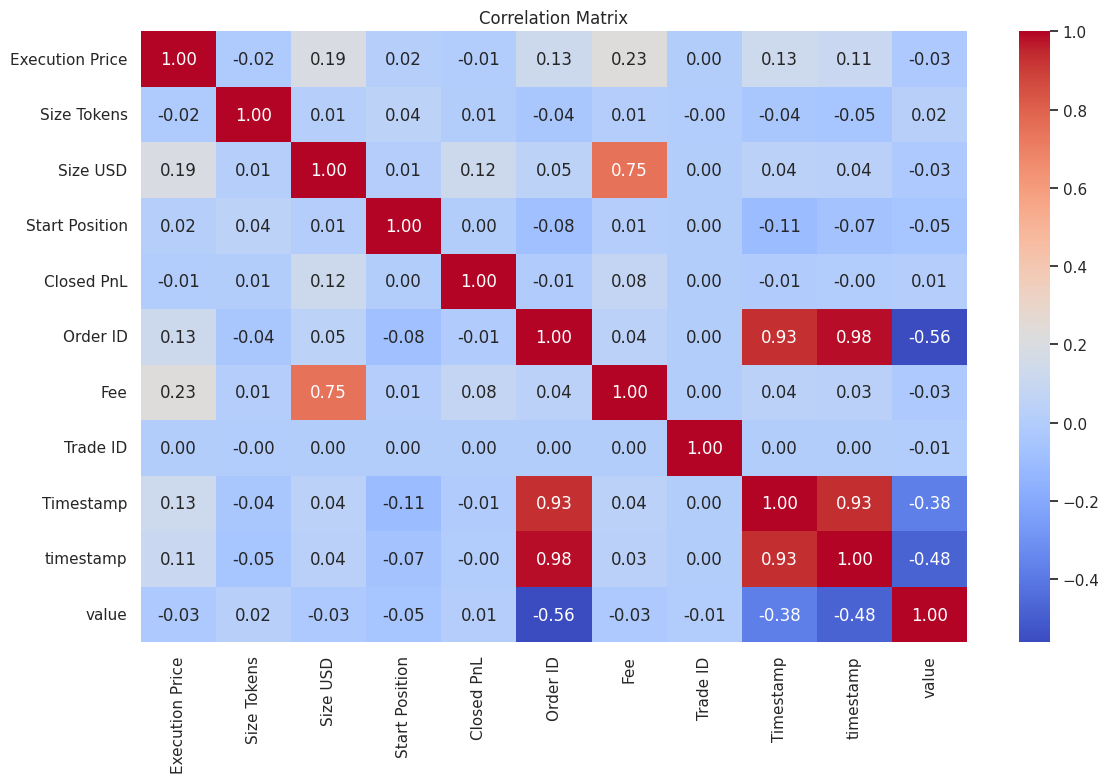

In [216]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

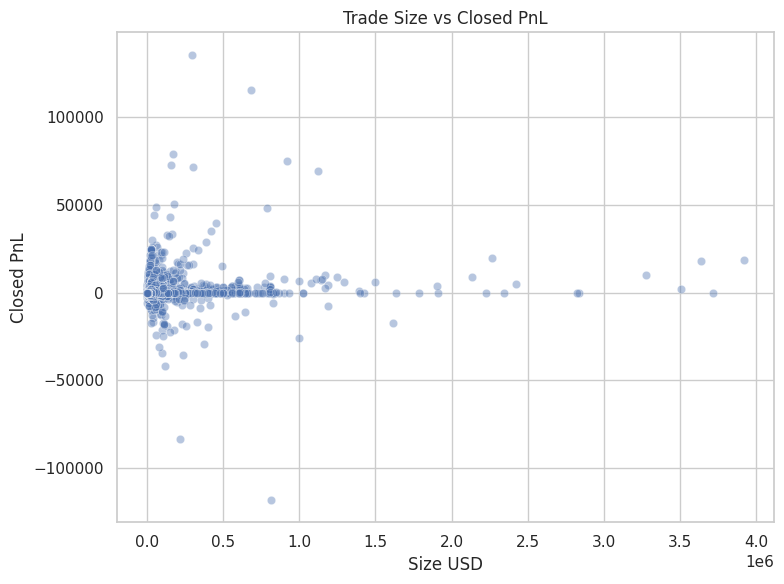

In [217]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x="Size USD",
    y="Closed PnL",
    alpha=0.4
)

plt.title("Trade Size vs Closed PnL")

plt.tight_layout()

plt.show()

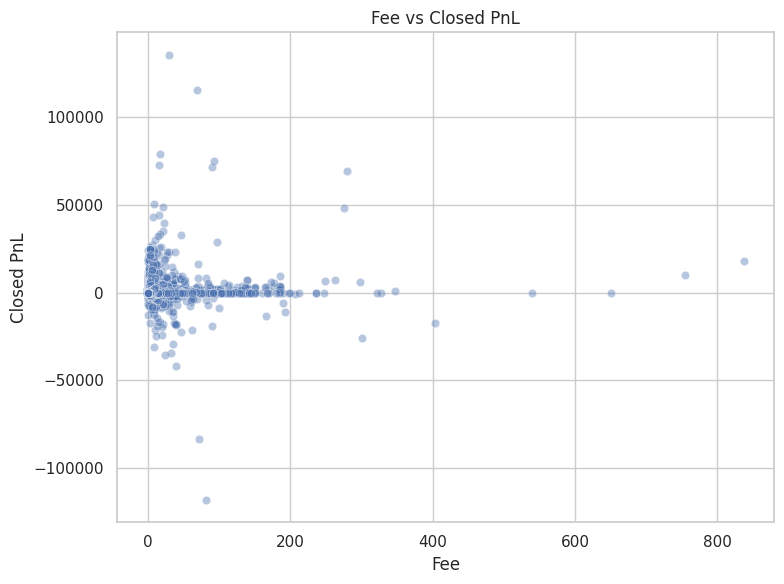

In [218]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x="Fee",
    y="Closed PnL",
    alpha=0.4
)

plt.title("Fee vs Closed PnL")

plt.tight_layout()

plt.show()

# Key Business Insights

In [219]:
# Profit Summary

insights = merged_df.groupby("classification").agg(
    Total_Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean"),
    Total_PnL=("Closed PnL","sum"),
    Average_Trade_Size=("Size USD","mean"),
    Average_Fee=("Fee","mean")
).round(2)

insights

,Total_Trades,Average_PnL,Total_PnL,Average_Trade_Size,Average_Fee
classification,,,,,
Extreme Fear,21400,34.54,739110.25,5349.73,1.12
Extreme Greed,39992,67.89,2715171.31,3112.25,0.68
Fear,61837,54.29,3357155.44,7816.11,1.50
Greed,50303,42.74,2150129.27,5736.88,1.25
Neutral,37686,34.31,1292920.68,4782.73,1.04


In [220]:
insights.to_csv(
    f"{PROJECT_PATH}/business_insights.csv"
)

print("Business Insights Saved")

Business Insights Saved


# Strategy Recommendations

## Recommendation 1

Adjust trading risk according to market sentiment. If historical analysis indicates weaker performance during Fear periods, traders should consider reducing position size and applying stricter risk management.

---

## Recommendation 2

Monitor trading behaviour alongside market sentiment rather than relying solely on price movements. Combining sentiment indicators with trader performance metrics can improve decision-making and reduce emotional trading.

---

## Recommendation 3

Track trader consistency instead of focusing only on total profits. A higher win rate with controlled risk may indicate a more sustainable trading strategy than occasional large profits.

# Executive Summary

This project analyzed the relationship between Bitcoin market sentiment and Hyperliquid trading performance by integrating historical trading records with the Bitcoin Fear & Greed Index.

The analysis included data preprocessing, exploratory data analysis, trader performance evaluation, correlation analysis, and sentiment-based comparisons.

Key findings indicate that market sentiment influences trading behaviour, profitability, trade size, and overall market participation. These insights can support better trading strategies and improve risk management by incorporating market sentiment into decision-making.

# Conclusion

The project successfully combined trading data with market sentiment data to evaluate trader behaviour under different market conditions.

The analysis demonstrated practical applications of data cleaning, feature engineering, visualization, statistical analysis, and business insight generation.

Future work could include leverage analysis, predictive modeling, and machine learning techniques to forecast trader performance based on market sentiment.

In [221]:
# Save Final Dataset

merged_df.to_csv(
    f"{PROJECT_PATH}/Final_Merged_Dataset.csv",
    index=False
)

print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

PROJECT COMPLETED SUCCESSFULLY


# Trader Segmentation

In [222]:
# Trader Performance Summary

trader_summary = merged_df.groupby("Account").agg(
    Total_Trades=("Closed PnL","count"),
    Total_PnL=("Closed PnL","sum"),
    Average_PnL=("Closed PnL","mean"),
    Average_Trade_Size=("Size USD","mean")
).round(2)

trader_summary.head()

,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.82,419.13,16159.58
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,47885.32,6.58,1653.23
0x271b280974205ca63b716753467d5a371de622ab,3809,-70436.19,-18.49,8893.00
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,132464.81,9.95,507.63
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,168658.00,52.07,3138.89


In [223]:
# Top 10 Consistent Traders

best_traders = trader_summary.sort_values(
    by="Average_PnL",
    ascending=False
).head(10)

best_traders

,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size
Account,,,,
0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,199505.59,520.90,5189.37
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.82,419.13,16159.58
0x430f09841d65beb3f27765503d0f850b8bce7713,1237,416541.87,336.74,2397.82
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,403011.50,281.83,2133.67
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,429355.57,270.03,7216.67
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,417,72846.48,174.69,2066.69
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,53496.25,161.13,3445.47
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,677747.05,155.59,9084.70
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2143382.60,145.48,3837.89


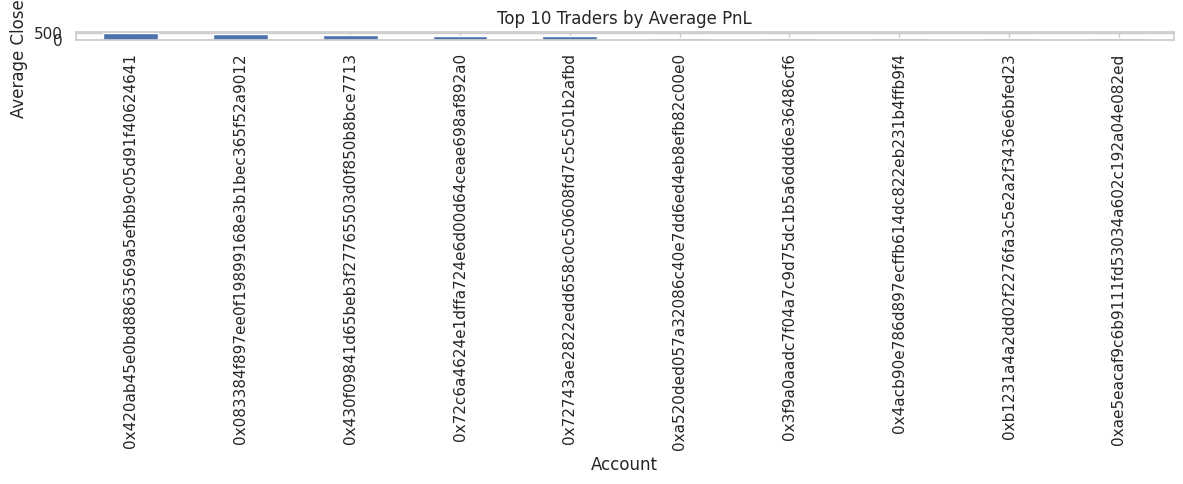

In [224]:
plt.figure(figsize=(12,5))

best_traders["Average_PnL"].plot(kind="bar")

plt.title("Top 10 Traders by Average PnL")

plt.ylabel("Average Closed PnL")

plt.tight_layout()

plt.show()

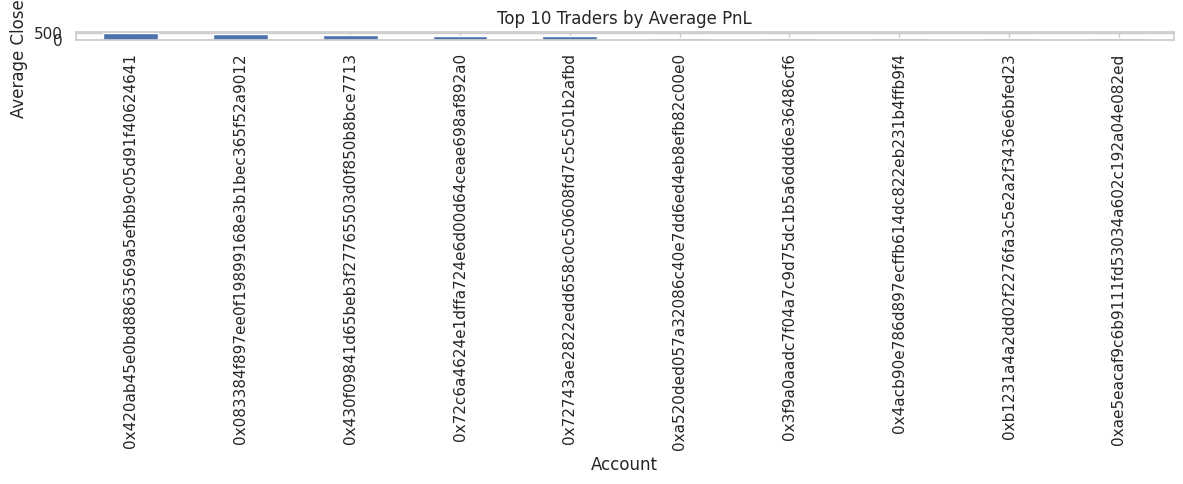

In [225]:
plt.figure(figsize=(12,5))

best_traders["Average_PnL"].plot(kind="bar")

plt.title("Top 10 Traders by Average PnL")

plt.ylabel("Average Closed PnL")

plt.tight_layout()

plt.show()

In [226]:
# Most Active Traders

active_traders = trader_summary.sort_values(
    by="Total_Trades",
    ascending=False
).head(10)

active_traders

,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size
Account,,,,
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,836080.55,20.81,1844.21
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,940163.81,44.36,3210.47
0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605,106302.88,6.81,1273.20
0x8477e447846c758f5a675856001ea72298fd9cb5,14998,43917.01,2.93,820.43
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2143382.60,145.48,3837.89
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,132464.81,9.95,507.63
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,840422.56,68.68,34396.58
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,379095.41,38.32,2600.78
0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8519,103343.72,12.13,517.53


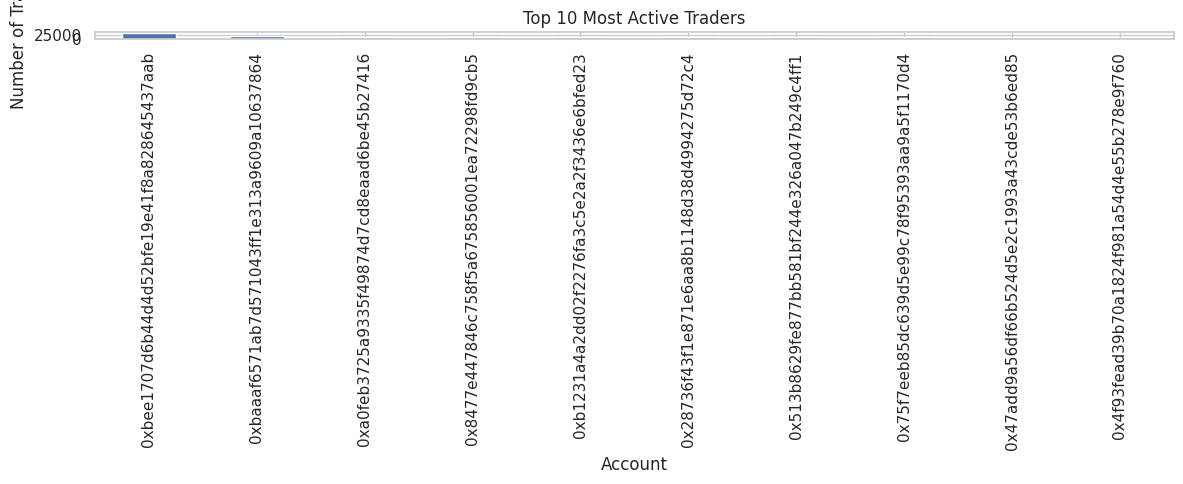

In [227]:
plt.figure(figsize=(12,5))

active_traders["Total_Trades"].plot(kind="bar")

plt.title("Top 10 Most Active Traders")

plt.ylabel("Number of Trades")

plt.tight_layout()

plt.show()

## Key Takeaways

- Market sentiment influences trader participation and profitability.
- Trading activity varies across different sentiment conditions.
- Trade size and trader performance differ between market environments.
- Some traders consistently outperform others, indicating differences in trading strategies and risk management.
- Sentiment data can be combined with trading history to support more informed trading decisions.

# Thank You

Thank you for reviewing my submission.

I appreciate the opportunity to complete this assignment and demonstrate my analytical, data processing, and visualization skills.

I look forward to discussing my approach and findings during the interview process.